# Fine-Tuning — Training DistilGPT-2 on ML Text

## Goal
Adapt DistilGPT-2 to understand ML/NLP domain text.
We train the model to predict the next token on our custom dataset.

## Training Setup
- Model: DistilGPT-2
- Task: Causal Language Modeling (next token prediction)
- Device: Apple MPS
- Dataset: 41 ML sentences (698 tokens)
- Goal: Reduce perplexity on ML text

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from transformers import GPT2Tokenizer, GPT2LMHeadModel
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Device: {device}")

Device: mps


## 1. Load Model and Data

In [2]:
# Load model and tokenizer
tokenizer = GPT2Tokenizer.from_pretrained("distilgpt2")
tokenizer.pad_token = tokenizer.eos_token
model = GPT2LMHeadModel.from_pretrained("distilgpt2")
model = model.to(device)

# Load training data
with open("../data/processed/ml_sentences.txt", "r") as f:
    sentences = [line.strip() for line in f if line.strip()]

print(f"Model loaded. Parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"Training sentences: {len(sentences)}")

Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

Model loaded. Parameters: 81,912,576
Training sentences: 41


## 2. Create Dataset

In [3]:
class MLTextDataset(Dataset):
    """
    Dataset for causal language modeling.
    Each item is a tokenized sentence with labels = input_ids (next token prediction).
    """

    def __init__(self, texts: list, tokenizer, max_lenght: int = 64):
        self.examples = []
        for text in texts:
            encoding = tokenizer(
                text,
                max_lenght=max_lenght,
                padding="max_length",
                truncation=True,
                return_tensors="pt"
            )
            input_ids = encoding.input_ids.squeeze()
            self.examples.append(input_ids)

    def __len__(self):
        return len(self.examples)

    def __getitem__(self, idx):
        input_ids = self.examples[idx]
        return {"input_ids": input_ids, "labels": input_ids}

dataset = MLTextDataset(sentences, tokenizer)
dataloader = DataLoader(dataset, batch_size=4, shuffle=True)

print(f"Dataset size: {len(dataset)}")
print(f"Batches per epoch: {len(dataloader)}")
print(f"Sample input shape: {dataset[0]["input_ids"].shape}")

Dataset size: 41
Batches per epoch: 11
Sample input shape: torch.Size([1024])


## 3. Training Loop

In [4]:
def train(model, dataloader, epochs: int = 10, learning_rate: float = 5e-5):
    """
    Fine-tune the model on the dataset.
    
    Args:
        model: GPT2LMHeadModel
        dataloader: DataLoader with training data
        epochs: Number of training epochs
        learning_rate: Learning rate for AdamW optimizer
    
    Returns:
        List of losses per epoch
    """
    optimizer = AdamW(model.parameters(), lr=learning_rate)
    model.train()

    epoch_losses = []

    for epoch in range(epochs):
        total_loss = 0
        num_batches = 0

        for batch in dataloader:
            input_ids = batch["input_ids"].to(device)
            labels = batch["labels"].to(device)

            optimizer.zero_grad()
            outputs = model(input_ids=input_ids, labels=labels)
            loss = outputs.loss
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            num_batches += 1

        avg_loss = total_loss / num_batches
        epoch_losses.append(avg_loss)

        if (epoch + 1) % 2 == 0:
            print(f"Epoch {epoch+1}/{epochs} - Loss: {avg_loss:.4f}")

    return epoch_losses


print("Starting fine-tuning...")
losses = train(model, dataloader, epochs=10, learning_rate=5e-5)
print(f"\nFinal loss: {losses[-1]:.4f}")

[transformers] `loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


Starting fine-tuning...
Epoch 2/10 - Loss: 0.1629
Epoch 4/10 - Loss: 0.0858
Epoch 6/10 - Loss: 0.0729
Epoch 8/10 - Loss: 0.0658
Epoch 10/10 - Loss: 0.0602

Final loss: 0.0602


## 4. Visualize Training Loss

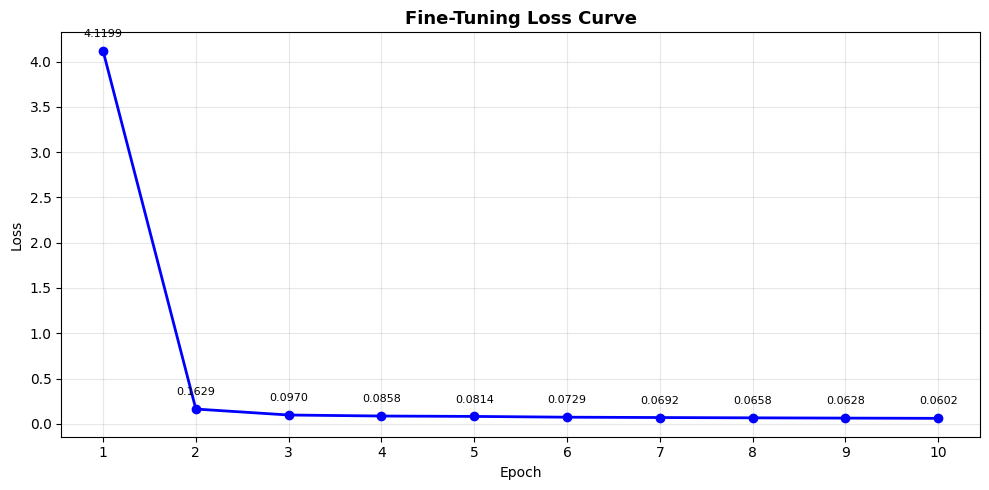

Loss reduction: 4.1199 → 0.0602
Improvement: 98.5%


error uploading: HTTPSConnectionPool(host='api.segment.io', port=443): Max retries exceeded with url: /v1/batch (Caused by NameResolutionError("<urllib3.connection.HTTPSConnection object at 0x12cf93b10>: Failed to resolve 'api.segment.io' ([Errno 8] nodename nor servname provided, or not known)"))


In [7]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(range(1, len(losses) + 1), losses, "b-o", linewidth=2, markersize=6)
ax.set_title("Fine-Tuning Loss Curve", fontsize=13, fontweight="bold")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.grid(True, alpha=0.3)
ax.set_xticks(range(1, len(losses) + 1))

for i, loss in enumerate(losses):
    ax.annotate(f"{loss:.4f}", (i+1, loss),
               textcoords="offset points", xytext=(0, 10),
               ha="center", fontsize=8)

plt.tight_layout()
plt.savefig("training_loss.png", dpi=300)
plt.show()

print(f"Loss reduction: {losses[0]:.4f} → {losses[-1]:.4f}")
print(f"Improvement: {(1 - losses[-1]/losses[0]) * 100:.1f}%")

## 5. Save Fine-Tuned Model

In [9]:
# Save model and tokenizer
save_path = "../models/distilgpt2-ml-finetuned"
model.save_pretrained(save_path)
tokenizer.save_pretrained(save_path)

print(f"Model saved to: {save_path}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved to: ../models/distilgpt2-ml-finetuned
